In [1]:
import argparse
import copy
import os
import gc
import glob
import time
import sys
# needs to be before torch import 

import torch
from torch.optim import *
from torch.optim.lr_scheduler import *
import numpy
import random
from typing import Dict, Tuple, List



In [2]:
random_seed = 42

In [3]:
torch.manual_seed(random_seed)
numpy.random.seed(random_seed)
random.seed(random_seed)


In [4]:
! pip install rich

In [5]:
from timeit import default_timer
import math
import statistics
import json
import numpy
from rich import box
from rich.console import Console
from rich.table import Table

In [6]:

class PerformanceMonitor():

    instance = None
    @staticmethod
    def get():
        if PerformanceMonitor.instance == None:
            PerformanceMonitor.instance = PerformanceMonitor()
        return PerformanceMonitor.instance

    def __init__(self):
        self.timings = {}
        self.current_times = {}
        self.logs = {}
        self.unique_logs = {}
        self.gpu_info = {}
    
    # we assume that we only use the same gpu model if we do multi-gpu training
    def set_gpu_info(self,count,model):
        self.gpu_info["gpu_model"] = model
        self.gpu_info["gpu_count"] = count

    def start_block(self,category:str):
        self.current_times[category] = default_timer()

    def log_value(self,name:str,value):
        if name not in self.logs:
            self.logs[name] = []
        self.logs[name].append(value)

    def log_unique_value(self,name:str,value):
        self.unique_logs[name] = value

    def stop_block(self,category:str,instances:int=1):
        if not category in self.timings:
            self.timings[category] = []

        self.timings[category].append((default_timer() - self.current_times[category], instances))

    def print_summary(self,console = None):
        if console == None:
            console = Console()

        table = Table(show_header=True, header_style="bold magenta")
        
        table.title = "Block-Timings"

        table.add_column("Block")
        table.add_column("Avg. it/s")
        table.add_column("Median Latency (ms)", justify="right")
        table.add_column("95th percentile latency (ms)", justify="right")
        table.add_column("Observations", justify="right")
        table.box = box.SIMPLE_HEAD

        for cat,data in self.timings.items():
            if len(data) == 1 and data[0][1] == 1:
                table.add_row(cat,"-", "{:.2f}".format(data[0][0]*1000),"-","1")
            else:
                #if len(data) > 1: # ignore the first as warm-up
                #    data = data[1:]
                per_iterations = [y/x for (x,y) in data]
                table.add_row(cat, "{:.2f}".format(statistics.median(per_iterations)),
                                   "{:.2f}".format(statistics.median([x*1000 for (x,_) in data])),
                                   "{:.2f}".format(numpy.percentile([x*1000 for (x,_) in data],95)),
                                   str(len(data)))
                #if cat == "search_nn_lookup":
                #    console.log("search_nn_lookup distribution")
                #    crappyhist([x*1000 for (x,_) in data],range_= (0,20))
        console.print(table)
        
        if len(self.unique_logs) > 0:
            table = Table(show_header=True, header_style="bold magenta")
            
            table.title = "Space / Memory Usage"
    
            table.add_column("Type")
            table.add_column("Space")
            table.box = box.SIMPLE_HEAD
    
            for cat,data in self.unique_logs.items():
                table.add_row(cat,str(data))
            
            console.print(table)

    def save_summary(self, file):
        
        summary = self.gpu_info.copy()
        total_gpu_hours = 0
        for cat,data in self.timings.items():
            cat_sum = {}
            times_only = [x for x,_ in data]
            if len(data) == 1 and data[0][1] == 1:
                cat_sum["type"] = "single_point"
                cat_sum["time"] = data[0][0]
            else:
                cat_sum["len"] = len(data)
                cat_sum["measure"] = "seconds"
                cat_sum["sum_times_gpus"] = sum(times_only) * self.gpu_info["gpu_count"]
                cat_sum["sum_gpu_hours"] = sum(times_only) * self.gpu_info["gpu_count"] / 60 / 60
                total_gpu_hours+=cat_sum["sum_gpu_hours"]
                cat_sum["sum"] = sum(times_only)

                #if len(data) > 2: # ignore the first as warm-up
                #    data = data[1:]
                per_iterations = [y/x for (x,y) in data]

                if len(per_iterations) > 1:
                    cat_sum["type"] = "list_iterations"
                    cat_sum["mean_perit"] = statistics.mean(per_iterations)
                    cat_sum["stdev_perit"] = statistics.stdev(per_iterations)
                    cat_sum["median_perit"] = statistics.median(per_iterations)
                    cat_sum["median_latency"] = statistics.median([x for (x,_) in data])
                    cat_sum["95th_latency"] = numpy.percentile([x for (x,_) in data],95)
                    cat_sum["observations"] = len(data)
                else:
                    cat_sum["type"] = "single_point_iterations"
                    cat_sum["perit"] = per_iterations

            summary[cat]=cat_sum

        for cat,data in self.logs.items():
            cat_sum = {}
            cat_sum["sum"] = statistics.mean(data) if len(data) > 1 else data[0]
            cat_sum["measure"] = "GB"
            summary[cat]=cat_sum

        for cat,data in self.unique_logs.items():
            cat_sum = {}
            cat_sum["values"] = data
            summary[cat]=cat_sum

        summary["total_gpu_hours"] = total_gpu_hours

        with open(file, "a") as out_file:
            json.dump(summary,out_file,indent=2)

In [7]:
cuda_device = 0 # always take the first -> set others via cuda flag in bash
perf_monitor = PerformanceMonitor.get()
perf_monitor.start_block("startup")

In [8]:
from transformers import AutoTokenizer

/workspace/2404170001/faiss-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
model = "/workspace/2404170001/e5-base-v2"
tokenizer = AutoTokenizer.from_pretrained(model)
padding_idx = tokenizer.pad_token_id


In [10]:
padding_idx

0

In [11]:
from typing import Dict, Union
import torch

from transformers import AutoModel
from transformers import PreTrainedModel,PretrainedConfig

In [13]:
class BERT_Dot_Config(PretrainedConfig):
    model_type = "e5-base"
    bert_model: str
    trainable: bool = True
    compress_dim: int = -1 # if -1 add no compression layer, otherwise add 1 single linear layer (from bert_out_dim to compress_dim)
    return_vecs: bool = False # whether to return the vectors in the training forward pass (for in-batch negative loss)


In [15]:

class BERT_Dot(PreTrainedModel):    
    """
    The main dense retrieval model;
    this model does not concat query and document, rather it encodes them sep. and uses a dot-product between the two cls vectors
    """

    config_class = BERT_Dot_Config
    base_model_prefix = "e5-base"

    @staticmethod
    def from_config(config):
        cfg = BERT_Dot_Config()
        cfg.bert_model          = config["bert_pretrained_model"]
        cfg.trainable           = config["bert_trainable"]
        cfg.return_vecs         = config.get("in_batch_negatives",False)
        cfg.compress_dim        = config.get("bert_dot_compress_dim",-1)
        return BERT_Dot(cfg)

    def __init__(self,
                 cfg) -> None:

        super().__init__(cfg)

        self.bert_model = AutoModel.from_pretrained(cfg.bert_model)

        for p in self.bert_model.parameters():
            p.requires_grad = cfg.trainable

        self.use_compressor = cfg.compress_dim > -1
        if self.use_compressor:
            self.compressor = torch.nn.Linear(self.bert_model.config.hidden_size, cfg.compress_dim)

        self.return_vecs = cfg.return_vecs

    #def reanimate(self,added_bias,layers):
    #    self.bert_model.reanimate(added_bias,layers)

    def forward(self,
                query: Dict[str, torch.LongTensor],
                document: Dict[str, torch.LongTensor],
                use_fp16:bool = True,
                output_secondary_output: bool = False) -> Dict[str, torch.Tensor]:
        
        with torch.cuda.amp.autocast(enabled=use_fp16):

            query_vecs = self.forward_representation(query)
            document_vecs = self.forward_representation(document)

            score = torch.bmm(query_vecs.unsqueeze(dim=1), document_vecs.unsqueeze(dim=2)).squeeze(-1).squeeze(-1)

            # used for in-batch negatives, we return them for multi-gpu sync -> out of the forward() method
            if self.training and self.return_vecs:
                score = (score, query_vecs, document_vecs)

            if output_secondary_output:
                return score, {}
            return score

    def forward_representation(self,
                               tokens: Dict[str, torch.LongTensor],
                               sequence_type="n/a") -> torch.Tensor:
        
        vectors = self.bert_model(**tokens)[0][:,0,:]

        if self.use_compressor:
            vectors = self.compressor(vectors)

        return vectors

    # override loading
    def from_pretrained(self, name:str):
        self.bert_model = AutoModel.from_pretrained(name)

    def get_param_stats(self):
        return "e5-base: / "
    def get_param_secondary(self):
        return {}

In [16]:
config={
    "bert_pretrained_model": "intfloat/e5-base",
    "bert_trainable": False,
    "in_batch_negatives": False,
    "bert_dot_compress_dim": 128
}
model = BERT_Dot.from_config(config)

In [17]:
model

BERT_Dot(
  (bert_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [18]:
import torch.nn as nn
class QuerySearcherHead(nn.Module):
    '''
    Wraps a nn.module and calls forward_representation in forward (needed for multi-gpu use)
    '''

    def __init__(self,
                 neural_ir_model: nn.Module,
                 use_fp16=True):

        super(QuerySearcherHead, self).__init__()

        self.neural_ir_model = neural_ir_model
        self.use_fp16 = use_fp16

    def forward(self, seq: Dict[str, torch.Tensor],search_type="encode",document_enc=None) -> torch.Tensor:
        with torch.cuda.amp.autocast(enabled=self.use_fp16):
            if search_type == "encode":
                vectors = self.neural_ir_model.forward_representation(seq, sequence_type="query_encode")
                return vectors
            elif search_type == "aggregate":
                scores = self.neural_ir_model.forward_aggregation(seq,document_enc)
                return scores

    def get_param_stats(self):
        return self.neural_ir_model.get_param_stats()

    def get_param_secondary(self):
        return self.neural_ir_model.get_param_secondary()


In [19]:
model_searcher = QuerySearcherHead(model,use_fp16=True).cuda()

In [20]:
perf_monitor.set_gpu_info(torch.cuda.device_count(),torch.cuda.get_device_name())

In [21]:
perf_monitor.stop_block("startup")
perf_monitor.start_block("inference")

In [22]:
token_base_size = 50000
token_dimensions = 768

In [23]:
seq_ids = []
id_mapping = []
storage = []

model_searcher.eval()

QuerySearcherHead(
  (neural_ir_model): BERT_Dot(
    (bert_model): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=76

In [24]:
max_query_length=30
max_doc_length=200
min_doc_length=-1
min_query_length=-1
collection_batch_size=256
query_batch_size=2000
use_fp16=True
dataloader_num_workers=6

In [25]:
class FastTransformerTokenizer():
    """
    basic wrapper for an HuggingFace AutoTokenizer
    """

    def __init__(self, model):

        self._tokenizer = AutoTokenizer.from_pretrained(model)

    def tokenize(self, sentence: str, sentence2: str = None, max_length: int = 512):
        if sentence2 != None:
            seq_tokenized = self._tokenizer(sentence, sentence2,
                                            max_length=max_length,
                                            truncation=True,
                                            return_tensors="pt",
                                            return_attention_mask=True)

        else:
            seq_tokenized = self._tokenizer(sentence,
                                            max_length=max_length,
                                            truncation=True,
                                            return_tensors="pt",
                                            return_attention_mask=True)

        for k, d in seq_tokenized.data.items():
            d.squeeze_(0)
        return seq_tokenized.data

In [26]:
_tokenizer = FastTransformerTokenizer("intfloat/e5-base")

In [27]:
def collate_fn(batch, max_length, pad_token_id):
    """
    Custom collate function to pad batches dynamically.
    Assumes batch items are dicts from tokenizer.
    """
    input_ids = [item["input_ids"] for item in batch]
    attention_mask = [item.get("attention_mask", [1] * len(item["input_ids"])) for item in batch]
    seq_ids = [item["seq_id"] for item in batch]

    max_len = min(max(len(ids) for ids in input_ids), max_length)

    padded_input_ids = torch.full((len(batch), max_len), pad_token_id, dtype=torch.long)
    padded_attention_mask = torch.zeros((len(batch), max_len), dtype=torch.long)

    for i, (ids, mask) in enumerate(zip(input_ids, attention_mask)):
        length = min(len(ids), max_len)
        padded_input_ids[i, :length] = torch.tensor(ids[:length])
        padded_attention_mask[i, :length] = torch.tensor(mask[:length])

    return {
        "seq_tokens": {
            "input_ids": padded_input_ids,
            "attention_mask": padded_attention_mask,
            # Add token_type_ids if needed
        },
        "seq_id": seq_ids
    }

In [28]:
from torch.utils.data import Dataset, DataLoader

In [29]:
class IdSequenceDataset(Dataset):
    """
    PyTorch Dataset for loading sequences from a TSV file: id<tab>text
    """
    def __init__(self, data_path, tokenizer, max_seq_length=-1, min_seq_length=-1, sequence_type="doc"):
        super().__init__()
        self.tokenizer = tokenizer
        self.max_seq_length = max_seq_length
        self.min_seq_length = min_seq_length
        self.sequence_type = sequence_type
        self.data = self._load_data(data_path)

    def _load_data(self, data_path):
        data = []
        with open(data_path, "r", encoding="utf8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split("\t")
                if len(parts) != 2:
                    raise ValueError(f"Invalid line format: {line}")
                seq_id, seq_text = parts
                data.append((seq_id, seq_text))
        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq_id, seq_text = self.data[idx]
        tokenized = self.tokenizer.tokenize(seq_text, max_length=self.max_seq_length)
        # For huggingface, tokenized is a dict with input_ids, attention_mask, etc.
        # Add seq_id
        tokenized["seq_id"] = seq_id
        return tokenized

In [30]:
def _get_indexer(model):
    _tokenizer = FastTransformerTokenizer(model["name"])
    return _tokenizer, None, None


In [31]:
def single_sequence_loader(model_config, run_config, input_file, sequence_type, force_exact_batch_size=False):
    """
    Load examples from a .tsv file in the single sequence format: id<tab>text
    Using PyTorch DataLoader.
    """
    if sequence_type == "query":
        max_length = model_config["max_query_length"]
        min_length = model_config["min_query_length"]
        batch_size = run_config["query_batch_size"]
    else:  # doc
        max_length = model_config["max_doc_length"]
        min_length = model_config["min_doc_length"]
        batch_size = run_config["collection_batch_size"]

    tokenizer, _, _ = _get_indexer(model_config)  # Reuse your _get_indexer, but we only need tokenizer

    dataset = IdSequenceDataset(input_file, tokenizer=tokenizer, max_seq_length=max_length, min_seq_length=min_length, sequence_type=sequence_type)

    # For huggingface tokenizer, get pad_token_id
    if isinstance(tokenizer, FastTransformerTokenizer):
        hf_tokenizer = AutoTokenizer.from_pretrained(model_config["bert_pretrained_model"])
        pad_token_id = hf_tokenizer.pad_token_id
    else:
        pad_token_id = 0  # Default, adjust if needed

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,  # Assuming inference, no shuffle
        num_workers=run_config["dataloader_num_workers"],
        collate_fn=lambda b: collate_fn(b, max_length, pad_token_id),
        pin_memory=True
    )
    return loader

In [32]:
input_loader = single_sequence_loader({
    "max_query_length": max_query_length,
    "min_query_length": min_query_length,
    "max_doc_length": max_doc_length,
    "min_doc_length": min_doc_length,
    "name":"sebastian-hofstaetter/distilbert-dot-tas_b-b256-msmarco",
    "bert_pretrained_model":"sebastian-hofstaetter/distilbert-dot-tas_b-b256-msmarco",
}, {
    "query_batch_size": query_batch_size,
    "dataloader_num_workers": dataloader_num_workers
}, "/workspace/2404170001/inputs/queries.train.tsv", sequence_type="query")

In [33]:
print("Storage shape:", storage.shape)

AttributeError: 'list' object has no attribute 'shape'

In [34]:
input_loader

In [35]:
def move_to_device(obj, device):
    """
    Recursively move tensors, modules, lists, tuples, or dicts to the specified device.
    Similar to AllenNLP's move_to_device.
    """
    if isinstance(obj, (list, tuple)):
        return type(obj)(move_to_device(x, device) for x in obj)
    elif isinstance(obj, dict):
        return {key: move_to_device(value, device) for key, value in obj.items()}
    elif isinstance(obj, torch.Tensor):
        return obj.to(device)
    elif isinstance(obj, torch.nn.Module):
        return obj.to(device)
    else:
        return obj

In [36]:
import json
from tqdm import tqdm as Tqdm

# For Params: If you're using it to load configuration from a JSON file or dict,
# you can replace with native Python json loading or a library like OmegaConf/YAML.
# Assuming simple JSON config, here's an example replacement:

class SimpleParams(dict):
    """
    A simple replacement for AllenNLP's Params class.
    Loads from dict or JSON file and allows dot-access like params.get('key').
    """
    @classmethod
    def from_file(cls, file_path):
        with open(file_path, 'r') as f:
            data = json.load(f)
        return cls(data)

    def get(self, key, default=None):
        return self.get(key, default)

    def pop(self, key, default=None):
        return self.pop(key, default)

    def as_dict(self):
        return dict(self)

In [37]:
with torch.no_grad():
    progress = Tqdm()
    i=0
    for batch_orig in input_loader:

        batch = move_to_device(copy.deepcopy(batch_orig), cuda_device)

        output = model_searcher.forward(batch["seq_tokens"])
        output = output.cpu().numpy()  # get the output back to the cpu - in one piece

        for sample_i, seq_id in enumerate(batch_orig["seq_id"]):
            id_mapping.append(len(seq_ids))
            seq_ids.append(seq_id)
        storage.append(output)

        progress.update()
        i+=1
    progress.close()

# save last token reps
storage = numpy.concatenate(storage,axis=0)
id_mapping = numpy.array(id_mapping,dtype=numpy.int64)

0it [00:00, ?it/s]/workspace/tmp/ipykernel_12421/2535950277.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded_input_ids[i, :length] = torch.tensor(ids[:length])
/workspace/tmp/ipykernel_12421/2535950277.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded_input_ids[i, :length] = torch.tensor(ids[:length])
/workspace/tmp/ipykernel_12421/2535950277.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded_attention_mask[i, :length] = torch.tensor(mask[:length])
/workspace/tmp/ipykernel_12421/2535950277.py:18: UserWarning:

In [38]:
storage

array([[-0.4736 , -0.3442 , -0.2375 , ...,  0.3232 ,  0.2888 , -0.05005],
       [-0.142  , -0.2344 , -0.06235, ..., -0.00609,  0.1451 ,  0.142  ],
       [-0.2966 , -0.4246 , -0.1605 , ..., -0.04434,  0.2333 , -0.05743],
       ...,
       [-0.2507 , -0.6733 ,  0.05026, ..., -0.2659 ,  0.3206 ,  0.02959],
       [-0.08264, -0.4978 ,  0.3901 , ...,  0.10815,  0.385  , -0.061  ],
       [-0.1434 , -0.8174 , -0.0931 , ...,  0.0121 ,  0.277  ,  0.2861 ]],
      dtype=float16)

In [39]:
id_mapping

array([     0,      1,      2, ..., 808728, 808729, 808730])

In [ ]:
!ls /tmp

In [40]:
run_folder="/workspace/2404170001/clustering_output_e5base"
os.makedirs(run_folder,exist_ok=True)

In [41]:
import zipfile
def saveCompressed(fh, **namedict):
    with zipfile.ZipFile(fh, mode="w", compression=zipfile.ZIP_STORED,
                            allowZip64=True) as zf:
        for k, v in namedict.items():
            with zf.open(k + '.npy', 'w', force_zip64=True) as buf:
                numpy.lib.npyio.format.write_array(buf,
                                                    numpy.asanyarray(v),
                                                    allow_pickle=True)

saveCompressed(os.path.join(run_folder,"query_vectors_n_ids.npz"),storage=storage,id_mapping=id_mapping,seq_ids=seq_ids)

perf_monitor.log_value("eval_gpu_mem",str(torch.cuda.memory_allocated()/float(1e9)) + " GB")
perf_monitor.log_value("eval_gpu_mem_max",str(torch.cuda.max_memory_allocated()/float(1e9)) + " GB")
perf_monitor.stop_block("inference")


In [42]:
from typing import Dict, Iterator, List

import faiss
import numpy
import os
import gc
#from faiss.contrib.ondisk import merge_ondisk
from rich.console import Console

In [43]:

class FaissDynamicIndexer():
    '''
    Wraps an IVF (inverted list with centroid mapping) faiss index, and provides methods for continuous updates of centroids 
    '''

    def __init__(self,config):
        super(FaissDynamicIndexer, self).__init__()
        self.faiss_index = None
        #faiss.IndexIVFScalarQuantizer(faiss.IndexHNSWSQ(config["token_dim"], faiss.ScalarQuantizer.QT_fp16, 12, faiss.METRIC_INNER_PRODUCT),config["token_dim"],config["faiss_ivf_lists"],faiss.ScalarQuantizer.QT_fp16,faiss.METRIC_INNER_PRODUCT)
        #self.faiss_index = faiss.IndexIVFFlat(config["token_dim"],config["faiss_ivf_lists"],faiss.ScalarQuantizer.QT_fp16,faiss.METRIC_INNER_PRODUCT)
        
        #self.faiss_index = faiss.IndexIDMap(faiss.index_factory(config["token_dim"],config["faiss_index_options"],faiss.METRIC_INNER_PRODUCT))
        self.list_n_probe = 1
        self.token_dim = config["token_dim"]
        self.faiss_ivf_list_count = config["faiss_ivf_list_count"]

    def prepare(self, data_chunks:List[numpy.ndarray], subsample=-1):
        '''
        subsample = -1, train on all vecs, if 0 - 1 train on fraction rand subset
        '''
        total_vecs = sum(arr.shape[0] for arr in data_chunks)

        inv_list_count = int(self.faiss_ivf_list_count) # * numpy.sqrt(total_vecs))

        self.faiss_index = faiss.IndexIVFScalarQuantizer(faiss.IndexFlatIP(self.token_dim),self.token_dim,inv_list_count,faiss.ScalarQuantizer.QT_fp16,faiss.METRIC_INNER_PRODUCT)
        self.faiss_index.set_direct_map_type(faiss.DirectMap.Hashtable)
        self.faiss_index.nprobe = self.list_n_probe

        if subsample > -1:
            max_train_sample = int(total_vecs * subsample)
            max_train_sample_per_chunk = max_train_sample // (len(data_chunks)-1)

            train_vecs = numpy.zeros((max_train_sample, data_chunks[0].shape[1]), dtype=numpy.float32)
            train_vecs[:,:] = 0

            rs = numpy.random.RandomState(123)
            for i, chunk in enumerate(data_chunks[:-1]):
                idx = rs.choice(chunk.shape[0], size=max_train_sample_per_chunk, replace=False)
                train_vecs[i*max_train_sample_per_chunk:(i+1)*max_train_sample_per_chunk] = chunk[idx]
        else:
            train_vecs = numpy.concatenate(data_chunks)
            max_train_sample = len(train_vecs)

        print("index with",total_vecs,"entries,",inv_list_count,"lists (avg-goal/list: ",total_vecs//inv_list_count,"); trained on",max_train_sample)

        self.faiss_index.train(train_vecs)


    def index_all(self, ids, data_chunks):
        for i, chunk in enumerate(data_chunks):
            #print(i,chunk.shape,ids[i].shape)
            # vectors must be float32, ids must be int64
            self.faiss_index.add_with_ids(chunk.astype(numpy.float32)[:len(ids[i])],numpy.array(ids[i],dtype="int64"))

        self.faiss_index.invlists.print_stats()
        print("imbalance factor",self.faiss_index.invlists.imbalance_factor())
        sizes = [self.faiss_index.invlists.list_size(i) for i in range(0,self.faiss_index.invlists.nlist)]
        print("median:",numpy.median(sizes))
        print("initial distibution")
        crappyhist(sizes,range_=(0,max(sizes)))

    def update(self, ids, data):

        ids = numpy.array(ids,dtype="int64")

        self.faiss_index.remove_ids(ids)
        
        # vectors must be float32, ids must be int64
        self.faiss_index.add_with_ids(data.astype(numpy.float32)[:len(ids)],ids)

        self.faiss_index.invlists.print_stats()
        print("imbalance factor",self.faiss_index.invlists.imbalance_factor())
        #sizes = [self.faiss_index.invlists.list_size(i) for i in range(0,self.faiss_index.invlists.nlist)]
        #print("updated distibution")
        #crappyhist(sizes,range_=(0,max(sizes)))

    def get_entries_from_centroids(self,centroid_ids):
        entry_ids = []
        for list_no in centroid_ids:
            list_sz = self.faiss_index.invlists.list_size(int(list_no))  # The length of list_no-th posting list

            # Fetch
            id_poslist = numpy.array(faiss.rev_swig_ptr(self.faiss_index.invlists.get_ids(int(list_no)), list_sz))

            entry_ids.extend(list(id_poslist))
        
        return entry_ids

    def get_all_cluster_assignments(self):
        clusters=[]
        for c in range(self.faiss_index.nlist):
            clusters.append(self.get_entries_from_centroids([c]))
        return clusters

    def search_single(self, query_vec,top_n):
        # even a single search must be 1xn dims
        if len(query_vec.shape) == 1:
            query_vec = query_vec[numpy.newaxis,:]
        
        query_vec = query_vec.astype(numpy.float32)

        #
        # get the nearest centroids (inverted list ids) first, so we know which centroid ids are touched
        #
        centroid_dist, centroid_ids = self.faiss_index.quantizer.search(query_vec,self.list_n_probe)

        #
        # search only on the centroid_ids we already have (saves to do that part twice)
        #
        numpy_res_ind = numpy.zeros((len(query_vec), top_n), dtype=numpy.int64)
        numpy_res_dist = numpy.zeros((len(query_vec), top_n), dtype=numpy.float32)
        # self.faiss_index.search_preassigned(len(query_vec),faiss.swig_ptr(query_vec),
        #                                     top_n,
        #                                     faiss.swig_ptr(centroid_ids),faiss.swig_ptr(centroid_dist),
        #                                     faiss.swig_ptr(numpy_res_dist),faiss.swig_ptr(numpy_res_ind),
        #                                     False,None)
        self.faiss_index.search_preassigned(
            query_vec,
            top_n,
            centroid_ids,
            centroid_dist,
            D=numpy_res_dist,
            I=numpy_res_ind
        )

        #invalidated_ids = self.get_entries_from_centroids(numpy_res_ind[0])
        # old direct search
        #res_scores, indices =  self.faiss_index.search(query_vec.astype(numpy.float32),top_n)

        return numpy_res_dist, numpy_res_ind, centroid_ids


    # coarse assignment
    #coarse_dis, assign = index.quantizer.search(xq, index.nprobe)
    #nlist = index.nlist
    #assign_buckets = assign // bs
    #nq = len(xq)
#
    #rh = faiss.ResultHeap(nq, k)
    #index.parallel_mode |= index.PARALLEL_MODE_NO_HEAP_INIT
#
    #for l0 in range(0, nlist, bs):
    #    bucket_no = l0 // bs
    #    skip_rows, skip_cols = np.where(assign_buckets != bucket_no)
    #    sub_assign = assign.copy()
    #    sub_assign[skip_rows, skip_cols] = -1
#
    #    index.search_preassigned(
    #        nq, faiss.swig_ptr(xq), k,
    #        faiss.swig_ptr(sub_assign), faiss.swig_ptr(coarse_dis),
    #        faiss.swig_ptr(rh.D), faiss.swig_ptr(rh.I),
    #        False, None
    #    )
#
    #rh.finalize()
#
    #return rh.D, rh.I

In [44]:
def crappyhist(a, bins=20, width=30,range_=(0,1)):
    h, b = numpy.histogram(a, bins,range_)

    for i in range (0, bins):
        print('{:12.5f}  | {:{width}s} {}'.format(
            b[i], 
            '#'*int(width*h[i]/numpy.amax(h)), 
            h[i],#/len(a), 
            width=width))
    print('{:12.5f}  |'.format(b[bins]))

In [ ]:
#
# nearest neighbor indexing
# -------------------------
perf_monitor.start_block("indexing")
config={
    "token_dim": 128,
    "faiss_ivf_list_count": 2000
}
indexer = FaissDynamicIndexer(config)

indexer.prepare([storage])
indexer.index_all([id_mapping], [storage])

perf_monitor.stop_block("indexing")

#
# cluster info output
# -------------------------
perf_monitor.start_block("output")

index with 808731 entries, 2000 lists (avg-goal/list:  404 ); trained on 808731
imbalance factor 1.1426118282682378
median: 386.0
initial distibution
     0.00000  |                                6
    57.35000  | #                              18
   114.70000  | ###                            44
   172.05000  | ###########                    130
   229.40000  | ##################             216
   286.75000  | ############################## 350
   344.10000  | ###########################    326
   401.45000  | ########################       291
   458.80000  | #####################          246
   516.15000  | ###########                    131
   573.50000  | ######                         79
   630.85000  | #####                          59
   688.20000  | ####                           49
   745.55000  | #                              21
   802.90000  |                                10
   860.25000  |                                8
   917.60000  |                              

list size in < 4: 1 instances
list size in < 32: 2 instances
list size in < 64: 4 instances
list size in < 128: 24 instances
list size in < 256: 254 instances
list size in < 512: 1322 instances
list size in < 1024: 389 instances
list size in < 2048: 4 instances


In [46]:
perf_monitor.start_block("output")

id_text={}
with open("/workspace/2404170001/inputs/queries.train.tsv","r",encoding="utf8") as qf:
    for l in qf:
        l=l.split("\t")
        id_text[l[0]] = l[1].strip()

clusters = [[] for _ in range(config["faiss_ivf_list_count"])]

input_loader = single_sequence_loader({
    "max_query_length": max_query_length,
    "min_query_length": min_query_length,
    "max_doc_length": max_doc_length,
    "min_doc_length": min_doc_length,
    "name":"sebastian-hofstaetter/distilbert-dot-tas_b-b256-msmarco",
    "bert_pretrained_model":"sebastian-hofstaetter/distilbert-dot-tas_b-b256-msmarco",
}, {
    "query_batch_size": query_batch_size,
    "dataloader_num_workers": dataloader_num_workers
}, "/workspace/2404170001/inputs/queries.train.tsv", sequence_type="query")

# input_loader = allennlp_single_sequence_loader(model_config,config, config["cluster_queries_tsv"], sequence_type="query")
with torch.no_grad():
    progress = Tqdm()
    i=0
    for batch_orig in input_loader:

        batch = move_to_device(copy.deepcopy(batch_orig), cuda_device)

        output = model_searcher.forward(batch["seq_tokens"])
        output = output.cpu().numpy()  # get the output back to the cpu - in one piece

        for sample_i, seq_id in enumerate(batch_orig["seq_id"]):
            _, _, centroid_ids = indexer.search_single(output[sample_i],1)

            clusters[int(centroid_ids)].append(seq_id)

        #    id_mapping.append(len(seq_ids))
        #    seq_ids.append(seq_id)
        #storage.append(output)

        progress.update()
        i+=1
    progress.close()




0it [00:00, ?it/s]/workspace/tmp/ipykernel_12421/2535950277.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded_input_ids[i, :length] = torch.tensor(ids[:length])
/workspace/tmp/ipykernel_12421/2535950277.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded_input_ids[i, :length] = torch.tensor(ids[:length])
/workspace/tmp/ipykernel_12421/2535950277.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  padded_input_ids[i, :length] = torch.tensor(ids[:length])
/workspace/tmp/ipykernel_12421/2535950277.py:17: UserWarning: To co

Visualizing top 200 clusters...
Running t-SNE on 10000 sampled vectors...


/workspace/tmp/ipykernel_12421/26890852.py:73: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


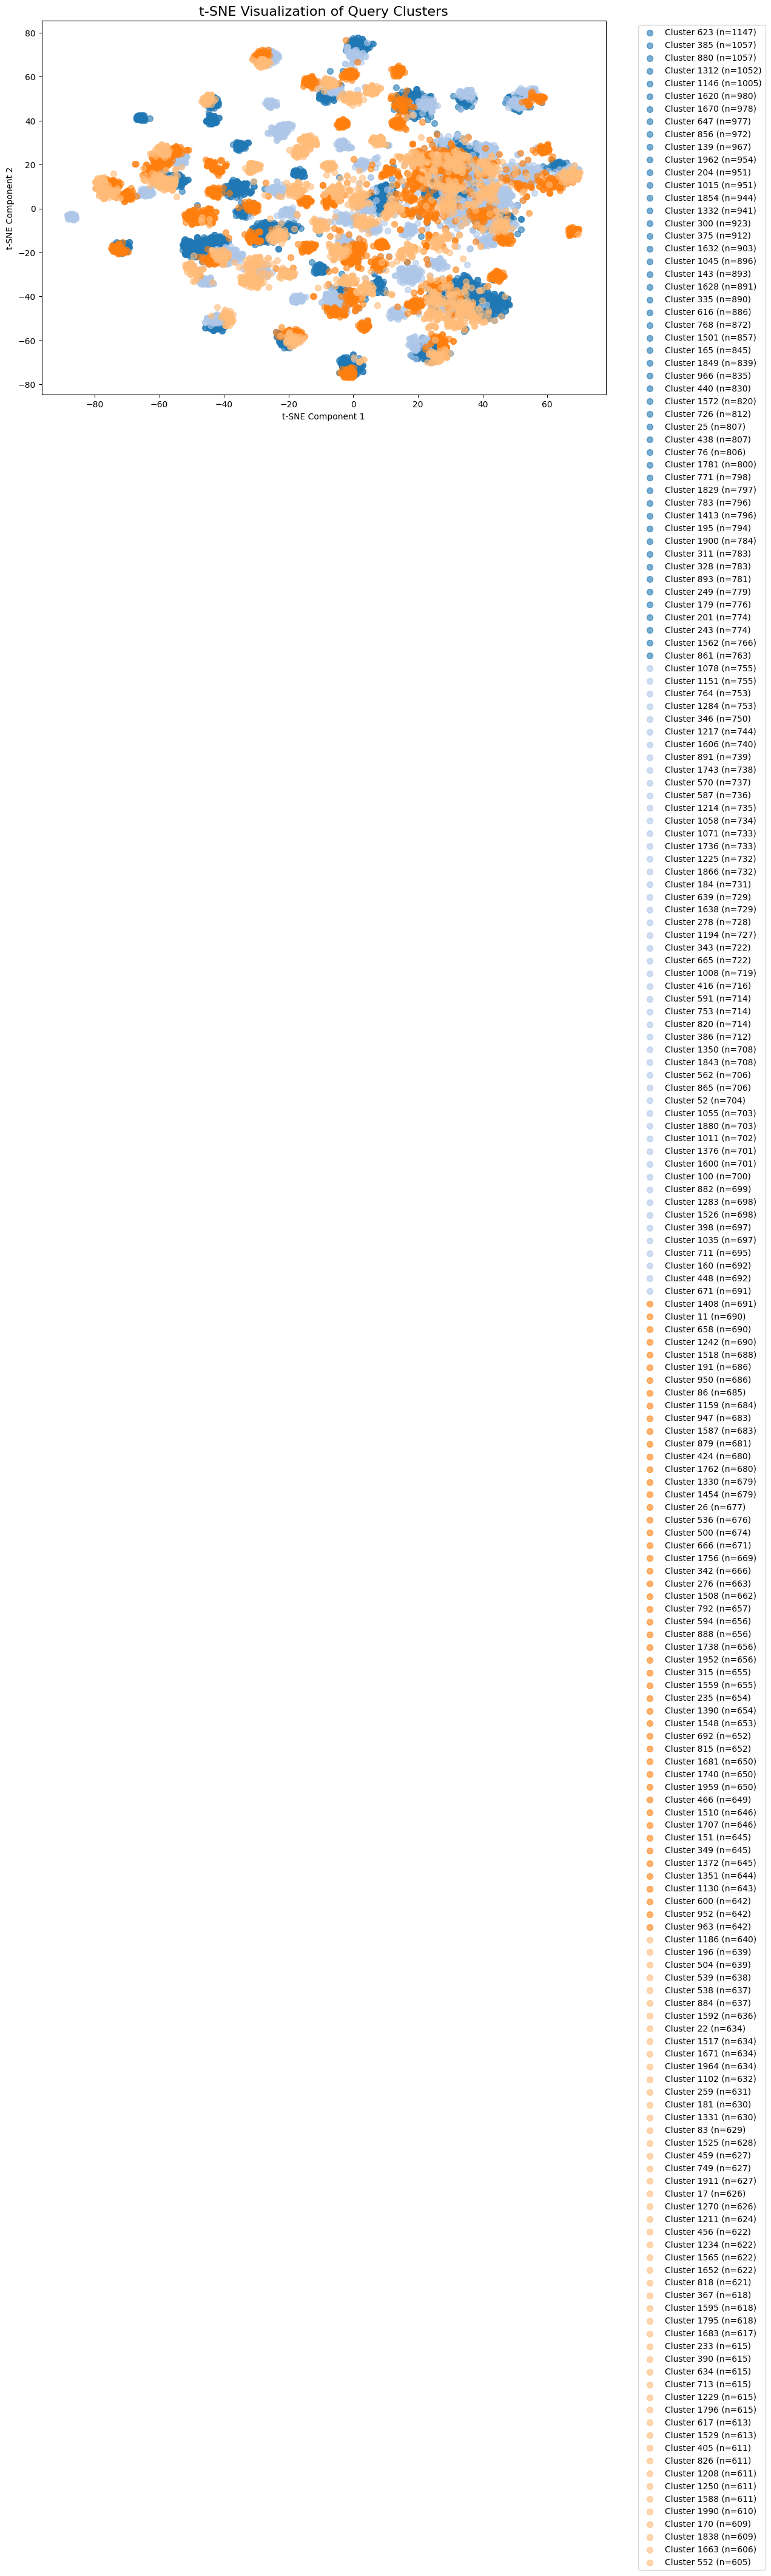

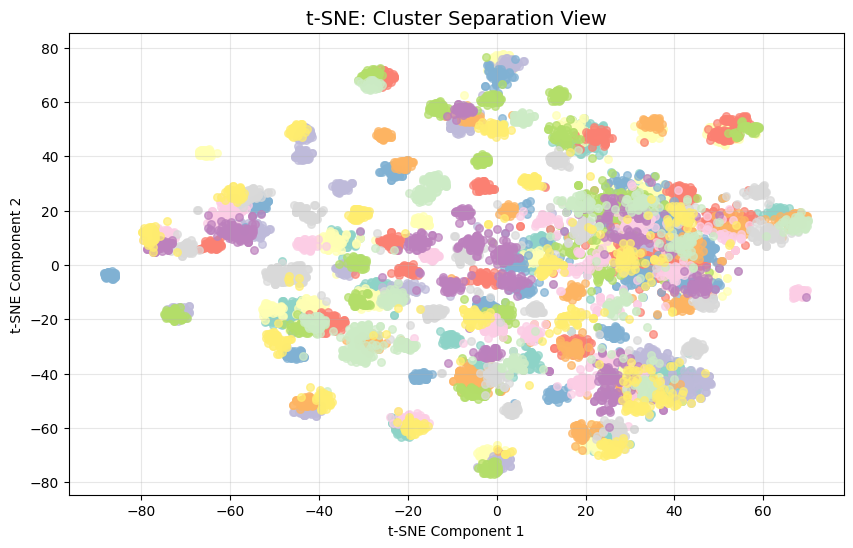

In [50]:
def visualize_clusters_tsne(storage, clusters, seq_ids, id_text, n_samples_per_cluster=50, random_state=42):
    """
    Create t-SNE visualization of query clusters
    """
    import matplotlib.pyplot as plt
    from sklearn.manifold import TSNE
    import numpy as np
    import random
    
    # Sample queries from clusters for visualization (to avoid overcrowding)
    sampled_vectors = []
    sampled_labels = []
    sampled_texts = []
    cluster_colors = plt.cm.tab20(np.linspace(0, 1, min(1000, len(clusters))))
    
    # Only visualize non-empty clusters
    non_empty_clusters = [(i, cluster) for i, cluster in enumerate(clusters) if len(cluster) > 0]
    
    # Sample top clusters by size for better visualization
    non_empty_clusters.sort(key=lambda x: len(x[1]), reverse=True)
    top_clusters = non_empty_clusters[:200]  # Show top 80 clusters

    print(f"Visualizing top {len(top_clusters)} clusters...")
    
    random.seed(random_state)
    
    for cluster_idx, (original_cluster_id, cluster_queries) in enumerate(top_clusters):
        # Sample queries from this cluster
        sample_size = min(n_samples_per_cluster, len(cluster_queries))
        sampled_query_ids = random.sample(cluster_queries, sample_size)
        
        for query_id in sampled_query_ids:
            # Find vector index for this query
            try:
                vector_idx = seq_ids.index(query_id)
                sampled_vectors.append(storage[vector_idx])
                sampled_labels.append(cluster_idx)
                sampled_texts.append(id_text.get(query_id, "Unknown query"))
            except ValueError:
                continue
    
    if len(sampled_vectors) == 0:
        print("No vectors found for visualization!")
        return
    
    sampled_vectors = np.array(sampled_vectors)
    sampled_labels = np.array(sampled_labels)
    
    print(f"Running t-SNE on {len(sampled_vectors)} sampled vectors...")
    
    # Run t-SNE
    tsne = TSNE(n_components=2, random_state=random_state, perplexity=min(30, len(sampled_vectors)//4))
    vectors_2d = tsne.fit_transform(sampled_vectors)
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    
    # Plot each cluster with different colors
    for cluster_idx in range(len(top_clusters)):
        mask = sampled_labels == cluster_idx
        if np.any(mask):
            original_cluster_id = top_clusters[cluster_idx][0]
            cluster_size = len(top_clusters[cluster_idx][1])
            plt.scatter(vectors_2d[mask, 0], vectors_2d[mask, 1], 
                       c=[cluster_colors[cluster_idx % len(cluster_colors)]], 
                       label=f'Cluster {original_cluster_id} (n={cluster_size})',
                       alpha=0.6, s=50)
    
    plt.title('t-SNE Visualization of Query Clusters', fontsize=16)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Also create a plot showing cluster separation
    plt.figure(figsize=(10, 6))
    unique_labels = np.unique(sampled_labels)
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = sampled_labels == label
        original_cluster_id = top_clusters[label][0]
        plt.scatter(vectors_2d[mask, 0], vectors_2d[mask, 1], 
                   c=[colors[i]], alpha=0.7, s=30,
                   label=f'Cluster {original_cluster_id}')
    
    plt.title('t-SNE: Cluster Separation View', fontsize=14)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return vectors_2d, sampled_labels, sampled_texts

# Run the t-SNE visualization
vectors_2d, labels_2d, texts_2d = visualize_clusters_tsne(storage, clusters, seq_ids, id_text)

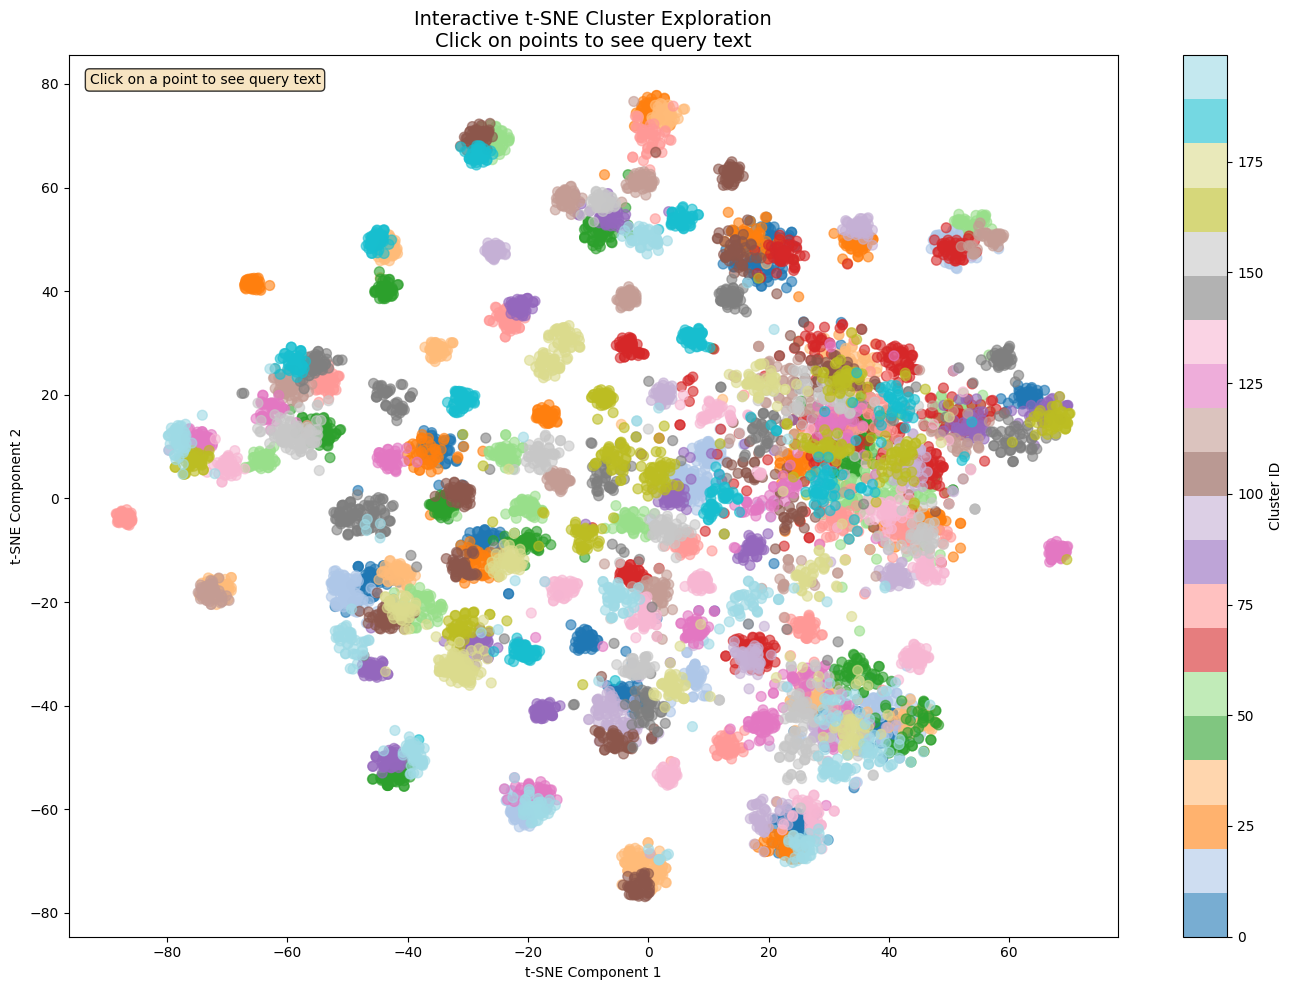

In [51]:
def interactive_cluster_exploration(vectors_2d, labels_2d, texts_2d, clusters):
    """
    Create an interactive exploration of the t-SNE plot
    """
    import matplotlib.pyplot as plt
    from matplotlib.widgets import Button
    import numpy as np
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Plot all points
    scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                        c=labels_2d, cmap='tab20', alpha=0.6, s=50)
    
    ax.set_title('Interactive t-SNE Cluster Exploration\nClick on points to see query text', fontsize=14)
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    
    # Add colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Cluster ID')
    
    # Text box for showing query text
    textbox = ax.text(0.02, 0.98, 'Click on a point to see query text', 
                     transform=ax.transAxes, fontsize=10, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    def on_click(event):
        if event.inaxes != ax:
            return
        
        # Find closest point
        distances = np.sqrt((vectors_2d[:, 0] - event.xdata)**2 + 
                          (vectors_2d[:, 1] - event.ydata)**2)
        closest_idx = np.argmin(distances)
        
        # Update text box
        query_text = texts_2d[closest_idx]
        cluster_id = labels_2d[closest_idx]
        textbox.set_text(f'Cluster {cluster_id}:\n"{query_text[:100]}..."')
        fig.canvas.draw()
    
    fig.canvas.mpl_connect('button_press_event', on_click)
    plt.tight_layout()
    plt.show()

# Run interactive exploration
interactive_cluster_exploration(vectors_2d, labels_2d, texts_2d, clusters)

Silhouette Score in t-SNE space: 0.2525


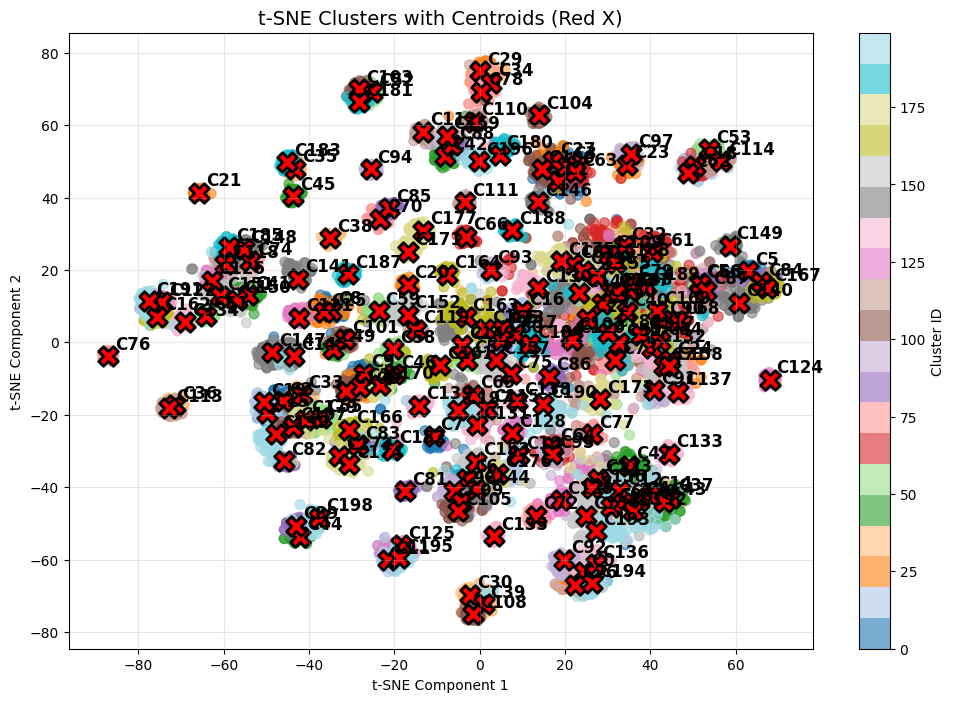


Inter-cluster distances (t-SNE space):
Cluster 0 ↔ Cluster 1: 108.136
Cluster 0 ↔ Cluster 2: 84.924
Cluster 0 ↔ Cluster 3: 112.363
Cluster 0 ↔ Cluster 4: 23.621
Cluster 0 ↔ Cluster 5: 91.568
Cluster 0 ↔ Cluster 6: 37.632
Cluster 0 ↔ Cluster 7: 51.522
Cluster 0 ↔ Cluster 8: 93.385
Cluster 0 ↔ Cluster 9: 75.261
Cluster 0 ↔ Cluster 10: 35.622
Cluster 0 ↔ Cluster 11: 45.978
Cluster 0 ↔ Cluster 12: 23.906
Cluster 0 ↔ Cluster 13: 69.797
Cluster 0 ↔ Cluster 14: 26.352
Cluster 0 ↔ Cluster 15: 86.264
Cluster 0 ↔ Cluster 16: 73.583
Cluster 0 ↔ Cluster 17: 67.755
Cluster 0 ↔ Cluster 18: 115.268
Cluster 0 ↔ Cluster 19: 88.406
Cluster 0 ↔ Cluster 20: 89.506
Cluster 0 ↔ Cluster 21: 138.339
Cluster 0 ↔ Cluster 22: 70.073
Cluster 0 ↔ Cluster 23: 113.021
Cluster 0 ↔ Cluster 24: 62.008
Cluster 0 ↔ Cluster 25: 94.226
Cluster 0 ↔ Cluster 26: 4.019
Cluster 0 ↔ Cluster 27: 113.812
Cluster 0 ↔ Cluster 28: 73.195
Cluster 0 ↔ Cluster 29: 140.433
Cluster 0 ↔ Cluster 30: 27.271
Cluster 0 ↔ Cluster 31: 25.333
Cl

In [52]:
def analyze_cluster_separation_tsne(vectors_2d, labels_2d, clusters):
    """
    Analyze how well clusters are separated in t-SNE space
    """
    import numpy as np
    from sklearn.metrics import silhouette_score
    import matplotlib.pyplot as plt
    
    # Calculate silhouette score in t-SNE space
    if len(np.unique(labels_2d)) > 1:
        tsne_silhouette = silhouette_score(vectors_2d, labels_2d)
        print(f"Silhouette Score in t-SNE space: {tsne_silhouette:.4f}")
    
    # Calculate cluster centroids in t-SNE space
    cluster_centroids = {}
    for label in np.unique(labels_2d):
        mask = labels_2d == label
        centroid = np.mean(vectors_2d[mask], axis=0)
        cluster_centroids[label] = centroid
    
    # Plot with centroids
    plt.figure(figsize=(12, 8))
    
    # Plot points
    scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], 
                         c=labels_2d, cmap='tab20', alpha=0.6, s=50)
    
    # Plot centroids
    for label, centroid in cluster_centroids.items():
        plt.scatter(centroid[0], centroid[1], 
                   c='red', marker='X', s=200, 
                   edgecolor='black', linewidth=2)
        plt.annotate(f'C{label}', (centroid[0], centroid[1]), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=12, fontweight='bold')
    
    plt.title('t-SNE Clusters with Centroids (Red X)', fontsize=14)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.colorbar(scatter, label='Cluster ID')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Calculate inter-cluster distances
    print("\nInter-cluster distances (t-SNE space):")
    labels = list(cluster_centroids.keys())
    for i, label1 in enumerate(labels):
        for j, label2 in enumerate(labels[i+1:], i+1):
            dist = np.linalg.norm(cluster_centroids[label1] - cluster_centroids[label2])
            print(f"Cluster {label1} ↔ Cluster {label2}: {dist:.3f}")

# Run separation analysis
analyze_cluster_separation_tsne(vectors_2d, labels_2d, clusters)

In [ ]:
!pip install matplotlib scikit-learn

In [53]:
#clusters = indexer.get_all_cluster_assignments()

with open(os.path.join(run_folder,"cluster-assignment-ids.tsv"),"w",encoding="utf8") as out_file,\
        open(os.path.join(run_folder,"cluster-assignment-text.tsv"),"w",encoding="utf8") as out_file_text:
    for clust in clusters:
        out_file.write("\t".join(idx for idx in clust)+"\n")
        out_file_text.write("\n".join(idx+"\t"+id_text[idx] for idx in clust)+\
                            "\n--------------------------------------------\n")

perf_monitor.stop_block("output")
perf_monitor.save_summary(os.path.join(run_folder,"perf-monitor.txt"))

1. Cluster Quality Metrics

In [ ]:

def evaluate_cluster_quality(storage, clusters, seq_ids):
    """
    Evaluate the quality of query clustering using internal metrics
    """
    from sklearn.metrics import silhouette_score, calinski_harabasz_score
    
    # Create cluster labels for each query
    cluster_labels = numpy.zeros(len(seq_ids))
    for cluster_id, query_ids in enumerate(clusters):
        for query_id in query_ids:
            # Find the index of this query_id in seq_ids
            query_idx = seq_ids.index(query_id)
            cluster_labels[query_idx] = cluster_id
    
    # Calculate clustering metrics
    silhouette_avg = silhouette_score(storage, cluster_labels)
    calinski_harabasz = calinski_harabasz_score(storage, cluster_labels)
    
    print(f"Silhouette Score: {silhouette_avg:.4f} (higher is better, range -1 to 1)")
    print(f"Calinski-Harabasz Index: {calinski_harabasz:.2f} (higher is better)")
    
    return silhouette_avg, calinski_harabasz

# Run the evaluation
silhouette, calinski = evaluate_cluster_quality(storage, clusters, seq_ids)

In [ ]:
!pip install scikit-learn

2. Semantic Coherence Analysis


In [54]:
def analyze_cluster_coherence(clusters, id_text, sample_size=5):
    """
    Analyze semantic coherence of clusters by sampling queries
    """
    print("=== CLUSTER COHERENCE ANALYSIS ===\n")
    
    # Sample some clusters for manual inspection
    import random
    sample_clusters = random.sample(range(len(clusters)), min(10, len(clusters)))
    
    for i, cluster_idx in enumerate(sample_clusters):
        cluster = clusters[cluster_idx]
        if len(cluster) == 0:
            continue
            
        print(f"Cluster {cluster_idx} (Size: {len(cluster)}):")
        print("-" * 50)
        
        # Sample queries from this cluster
        sample_queries = random.sample(cluster, min(sample_size, len(cluster)))
        
        for query_id in sample_queries:
            if query_id in id_text:
                print(f"  {query_id}: {id_text[query_id]}")
        
        print("\n")

# Run coherence analysis
analyze_cluster_coherence(clusters, id_text)

=== CLUSTER COHERENCE ANALYSIS ===

Cluster 1202 (Size: 292):
--------------------------------------------------
  41240: average rainfall crescent city florida
  47651: average yearly rain in los angeles
  30987: average annual precipitation catskill ny
  41336: average rainfall uk map
  41279: average rainfall in houston,texas in winter


Cluster 1609 (Size: 447):
--------------------------------------------------
  633549: what does brocha para maquillaje mean
  1152571: what is spanish for where?
  653652: what does the word puedo mean in spanish
  403637: is avila a spanish last name?
  752514: what is grapes in spanish


Cluster 1131 (Size: 315):
--------------------------------------------------
  217632: how do i command bixby
  381193: how to start teamviewer
  353602: how to create minif function
  385933: how to view chkdsk log
  223967: how do you sign botty in asl


Cluster 1551 (Size: 390):
--------------------------------------------------
  764663: what is lava rock cal

3. Cluster Size Distribution Analysis


In [55]:
def analyze_cluster_distribution(clusters):
    """
    Analyze cluster size distribution and balance
    """
    cluster_sizes = [len(cluster) for cluster in clusters]
    non_empty_clusters = [size for size in cluster_sizes if size > 0]
    
    print("=== CLUSTER DISTRIBUTION ANALYSIS ===")
    print(f"Total clusters: {len(clusters)}")
    print(f"Non-empty clusters: {len(non_empty_clusters)}")
    print(f"Empty clusters: {len(clusters) - len(non_empty_clusters)}")
    print(f"Average cluster size: {numpy.mean(non_empty_clusters):.2f}")
    print(f"Median cluster size: {numpy.median(non_empty_clusters):.2f}")
    print(f"Min cluster size: {min(non_empty_clusters)}")
    print(f"Max cluster size: {max(non_empty_clusters)}")
    print(f"Standard deviation: {numpy.std(non_empty_clusters):.2f}")
    
    # Distribution buckets (as you showed earlier)
    buckets = [16, 32, 64, 128, 256, 512, 1024, 2048]
    print("\nCluster size distribution:")
    for i, bucket in enumerate(buckets):
        if i == 0:
            count = sum(1 for size in cluster_sizes if size < bucket)
            print(f"< {bucket}: {count} clusters")
        else:
            count = sum(1 for size in cluster_sizes if buckets[i-1] <= size < bucket)
            print(f"{buckets[i-1]} - {bucket}: {count} clusters")
    
    # Check balance according to paper (should average ~404 per cluster)
    expected_avg = 808731 / 2000  # Total queries / clusters
    print(f"\nExpected average (paper): {expected_avg:.0f}")
    print(f"Actual average: {numpy.mean(non_empty_clusters):.2f}")
    print(f"Balance ratio: {numpy.mean(non_empty_clusters) / expected_avg:.3f}")

# Run distribution analysis
analyze_cluster_distribution(clusters)

=== CLUSTER DISTRIBUTION ANALYSIS ===
Total clusters: 2000
Non-empty clusters: 2000
Empty clusters: 0
Average cluster size: 404.37
Median cluster size: 386.00
Min cluster size: 3
Max cluster size: 1147
Standard deviation: 152.70

Cluster size distribution:
< 16: 1 clusters
16 - 32: 2 clusters
32 - 64: 4 clusters
64 - 128: 24 clusters
128 - 256: 254 clusters
256 - 512: 1324 clusters
512 - 1024: 387 clusters
1024 - 2048: 4 clusters

Expected average (paper): 404
Actual average: 404.37
Balance ratio: 1.000


4. Topic Coherence Validation


In [56]:
def extract_cluster_keywords(clusters, id_text, top_k=5):
    """
    Extract top keywords from each cluster to verify topic coherence
    """
    from collections import Counter
    import re
    
    print("=== CLUSTER KEYWORD ANALYSIS ===\n")
    
    # Sample some clusters for keyword analysis
    import random
    sample_clusters = random.sample(range(len(clusters)), min(5, len(clusters)))
    
    for cluster_idx in sample_clusters:
        cluster = clusters[cluster_idx]
        if len(cluster) < 10:  # Skip small clusters
            continue
            
        # Collect all text from this cluster
        cluster_text = []
        for query_id in cluster:
            if query_id in id_text:
                # Simple text preprocessing
                text = id_text[query_id].lower()
                # Remove common stop words and extract meaningful words
                words = re.findall(r'\b[a-zA-Z]{3,}\b', text)
                cluster_text.extend(words)
        
        # Get most common words
        word_counts = Counter(cluster_text)
        top_words = word_counts.most_common(top_k)
        
        print(f"Cluster {cluster_idx} (Size: {len(cluster)}):")
        print(f"Top keywords: {', '.join([word for word, count in top_words])}")
        print(f"Sample queries:")
        for i, query_id in enumerate(random.sample(cluster, min(3, len(cluster)))):
            if query_id in id_text:
                print(f"  {i+1}. {id_text[query_id]}")
        print("\n")

# Run keyword analysis
extract_cluster_keywords(clusters, id_text)

=== CLUSTER KEYWORD ANALYSIS ===

Cluster 385 (Size: 1057):
Top keywords: who, the, what, was, chris
Sample queries:
  1. who is panda
  2. who is upmc
  3. who is kotter


Cluster 972 (Size: 321):
Top keywords: definition, what, define, the, meaning
Sample queries:
  1. the standard definition of recession is
  2. sexual pleasure definition
  3. emotional intelligence definition goleman


Cluster 222 (Size: 522):
Top keywords: number, phone, customer, for, service
Sample queries:
  1. minnesota state insurance phone number
  2. us xpress south carolina phone number
  3. dade county clerk of courts phone number


Cluster 673 (Size: 360):
Top keywords: cost, average, for, weighted, price
Sample queries:
  1. historical average return on investment
  2. finding the relative price
  3. total material cost variance


Cluster 1166 (Size: 384):
Top keywords: how, outlook, email, mail, from
Sample queries:
  1. how do you delete emails
  2. how to change name on outlook email account
  3. how

5. Comparison with Paper Benchmarks


In [57]:
def validate_against_paper_benchmarks(clusters, total_queries=808731):
    """
    Validate clustering results against TAS-Balanced paper benchmarks
    """
    print("=== PAPER BENCHMARK VALIDATION ===")
    
    # Paper specifications from Section 4.2
    expected_clusters = 2000
    expected_avg_size = total_queries / expected_clusters
    
    non_empty_clusters = [len(cluster) for cluster in clusters if len(cluster) > 0]
    actual_clusters = len(non_empty_clusters)
    actual_avg_size = numpy.mean(non_empty_clusters)
    
    print(f"Expected clusters: {expected_clusters}")
    print(f"Actual clusters (non-empty): {actual_clusters}")
    print(f"Cluster utilization: {actual_clusters/expected_clusters*100:.1f}%")
    
    print(f"\nExpected average cluster size: {expected_avg_size:.0f}")
    print(f"Actual average cluster size: {actual_avg_size:.2f}")
    print(f"Size accuracy: {actual_avg_size/expected_avg_size*100:.1f}%")
    
    # Check if most clusters are in reasonable range (paper shows 256-512 range)
    reasonable_size = sum(1 for size in non_empty_clusters if 100 <= size <= 800)
    print(f"\nClusters in reasonable size range (100-800): {reasonable_size}/{actual_clusters} ({reasonable_size/actual_clusters*100:.1f}%)")
    
    # Overall validation
    if (0.8 <= actual_avg_size/expected_avg_size <= 1.2 and 
        actual_clusters >= 0.8 * expected_clusters and
        reasonable_size/actual_clusters >= 0.7):
        print("\n✅ CLUSTERING VALIDATION: PASSED")
        print("Your clustering results align well with the TAS-Balanced paper!")
    else:
        print("\n❌ CLUSTERING VALIDATION: NEEDS REVIEW")
        print("Consider adjusting clustering parameters.")

# Run validation
validate_against_paper_benchmarks(clusters)

=== PAPER BENCHMARK VALIDATION ===
Expected clusters: 2000
Actual clusters (non-empty): 2000
Cluster utilization: 100.0%

Expected average cluster size: 404
Actual average cluster size: 404.37
Size accuracy: 100.0%

Clusters in reasonable size range (100-800): 1953/2000 (97.7%)

✅ CLUSTERING VALIDATION: PASSED
Your clustering results align well with the TAS-Balanced paper!


 Manual Quality Check

In [58]:
def manual_quality_check(clusters, id_text):
    """
    Manual quality check - inspect specific clusters
    """
    print("=== MANUAL QUALITY CHECK ===\n")
    
    # Find clusters with different sizes for inspection
    cluster_sizes = [(i, len(cluster)) for i, cluster in enumerate(clusters)]
    cluster_sizes.sort(key=lambda x: x[1], reverse=True)
    
    # Check largest cluster
    largest_cluster_idx = cluster_sizes[0][0]
    print(f"LARGEST CLUSTER ({cluster_sizes[0][1]} queries):")
    for i, query_id in enumerate(clusters[largest_cluster_idx][:10]):
        if query_id in id_text:
            print(f"  {i+1}. {id_text[query_id]}")
    
    # Check medium-sized cluster
    medium_cluster_idx = cluster_sizes[len(cluster_sizes)//2][0]
    print(f"\nMEDIUM CLUSTER ({cluster_sizes[len(cluster_sizes)//2][1]} queries):")
    for i, query_id in enumerate(clusters[medium_cluster_idx][:10]):
        if query_id in id_text:
            print(f"  {i+1}. {id_text[query_id]}")

# Run manual check
manual_quality_check(clusters, id_text)

=== MANUAL QUALITY CHECK ===

LARGEST CLUSTER (1147 queries):
  1. uveitis signs and symptoms
  2. symptoms of low male hormone levels
  3. speech impairment symptoms
  4. symptoms of malignant uterine polyps
  5. neuropathy pain symptoms
  6. mineral iron deficiency symptoms
  7. symptoms if ovarian cancer
  8. symptoms of severe gallbladder stone
  9. what are symptoms of a kidney cyst
  10. symptoms of peripheral angiopathy

MEDIUM CLUSTER (386 queries):
  1. was the actress who played carol pregnant
  2. has cyndi lauper had cosmetic surgery
  3. is mitch mcconnell really gay
  4. did glen campbell have any children
  5. was josie bissett married to rob estes
  6. is shawn killinger pregnant again
  7. did lea bowman really sing in his movie
  8. did george clooney have baby
  9. did scarlett johansson sing in sing
  10. does chris cuomo have daughters


Expected Good Results
Based on the TAS-Balanced paper, you should see:

Cluster sizes: Most clusters between 200-600 queries
Silhouette score: > 0.1 (indicating reasonable separation)
Topic coherence: Queries within clusters should share semantic themes
Balance: ~95% of clusters should be non-empty and reasonably sized

In [ ]:
! ls /tmp/clustering_output1  